# Donor Churn / Lapse Risk Classifier

## Lighthouse Sanctuary — INTEX W26

---

## 1. Business Understanding

**Goal:** Predict each donor's probability of lapsing (churning) using behavioural donation patterns, and surface the model's top contributing factors.

**Approach:** We use RFM analysis (Recency, Frequency, Monetary value) combined with behavioural features (donation variety, recurring status, acquisition channel) to train a classifier. The primary output is a **continuous churn probability score** (0–100%), not a binary yes/no label. This lets staff prioritize outreach by seeing "73% churn risk — top factors: recency, frequency, avg gap days" rather than just "at risk."

**Target definition:** A donor is labelled "at risk" if their recency (days since last donation) exceeds the 75th percentile of all donors. This makes the threshold relative to the data distribution rather than an arbitrary 180-day cutoff.

### Small Data Caveat
With only 60 supporters and ~420 donations, this dataset is small for ML. We use `RepeatedStratifiedKFold` cross-validation for stable estimates. **The churn probability score and feature importance matter more than hitting a specific accuracy number.**

In [ ]:
# If running in Google Colab, uncomment the next two lines:
# from google.colab import drive
# drive.mount("/content/drive")


---

## 2. Data Understanding

This section explores the two source datasets — `supporters` (60 records) and `donations` (420 records) — to understand the shape, quality, and patterns in the data before any modeling. The goal is to build intuition about donor behavior: how often do supporters give, through which channels, and how much variation exists in giving patterns?

**Key questions guiding this exploration:**
- What types of supporters does the organization have, and how were they acquired?
- What does the donation distribution look like — is it concentrated among a few donors or spread evenly?
- Are there temporal patterns in giving behavior?
- How much missingness exists, and is it structural or random?


In [ ]:
# ============================================================
# Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     RepeatedStratifiedKFold)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

from statsmodels.stats.outliers_influence import variance_inflation_factor

import joblib
import json
from datetime import datetime, timezone

sns.set_style("whitegrid")
SEED = 42

# ---- Business parameter ----
# Adjust this threshold to change the definition of "at risk".
# 180 days = ~6 months without a donation.
CHURN_THRESHOLD_DAYS = 180

In [ ]:
# ============================================================
# 2a. Load source tables
# ============================================================
USE_DATABASE = False  # flip to True once Azure SQL connection string is available

if USE_DATABASE:
    from sqlalchemy import create_engine
    CONNECTION_STRING = ""  # <-- paste Azure SQL connection string here
    engine = create_engine(CONNECTION_STRING)
    supporters = pd.read_sql("SELECT * FROM supporters", engine)
    donations  = pd.read_sql("SELECT * FROM donations",  engine)
else:
    BASE = "../data/"
    supporters = pd.read_csv(BASE + "supporters.csv")
    donations  = pd.read_csv(BASE + "donations.csv")

print(f"supporters: {supporters.shape}")
print(f"donations:  {donations.shape}")
print()
display(supporters.head())
display(donations.head())

supporters: (60, 15)
donations:  (420, 13)



,supporter_id,supporter_type,display_name,organization_name,first_name,last_name,relationship_type,region,country,email,phone,status,created_at,first_donation_date,acquisition_channel
0,1,SocialMediaAdvocate,Mila Alvarez,NaN,Mila,Alvarez,Local,Luzon,Philippines,mila-alvarez@smart.com.ph,+63 997 578 1887,Active,2022-01-01 00:00:00,2023-07-02,SocialMedia
1,2,Volunteer,Aria Brown,NaN,Aria,Brown,Local,Mindanao,Philippines,aria-brown@pldt.net.ph,+63 927 354 4139,Active,2022-01-06 00:00:00,2023-09-25,SocialMedia
2,3,MonetaryDonor,Noah Chen,NaN,Noah,Chen,Local,Luzon,Philippines,noah-chen@globe.com.ph,+63 917 553 2604,Active,2022-01-11 00:00:00,2023-06-25,SocialMedia
3,4,MonetaryDonor,Liam Diaz,NaN,Liam,Diaz,PartnerOrganization,Mindanao,Philippines,liam-diaz@globe.com.ph,+63 945 516 8956,Active,2022-01-16 00:00:00,2026-03-01,Church
4,5,InKindDonor,Emma Evans,NaN,Emma,Evans,PartnerOrganization,Mindanao,Philippines,emma-evans@yahoo.com.ph,+63 995 371 8454,Active,2022-01-21 00:00:00,2024-01-18,Website


,donation_id,supporter_id,donation_type,donation_date,is_recurring,campaign_name,channel_source,currency_code,amount,estimated_value,impact_unit,notes,referral_post_id
0,1,42,Monetary,2025-12-31,False,NaN,Campaign,PHP,717.18,717.18,pesos,In support of safehouse operations,NaN
1,2,25,Time,2025-12-02,True,Year-End Hope,Event,NaN,NaN,35.15,hours,Community outreach support,NaN
2,3,19,Monetary,2024-12-02,False,NaN,PartnerReferral,PHP,1074.65,1074.65,pesos,Campaign support,NaN
3,4,33,Monetary,2023-09-11,False,NaN,PartnerReferral,PHP,1230.56,1230.56,pesos,In support of safehouse operations,NaN
4,5,24,InKind,2023-11-08,True,GivingTuesday,SocialMedia,NaN,NaN,1177.41,items,In support of safehouse operations,421.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   supporter_id         60 non-null     int64 
 1   supporter_type       60 non-null     object
 2   display_name         60 non-null     object
 3   organization_name    4 non-null      object
 4   first_name           56 non-null     object
 5   last_name            56 non-null     object
 6   relationship_type    60 non-null     object
 7   region               60 non-null     object
 8   country              60 non-null     object
 9   email                60 non-null     object
 10  phone                60 non-null     object
 11  status               60 non-null     object
 12  created_at           60 non-null     object
 13  first_donation_date  59 non-null     object
 14  acquisition_channel  60 non-null     object
dtypes: int64(1), object(14)
memory usage: 7.2+ KB


None

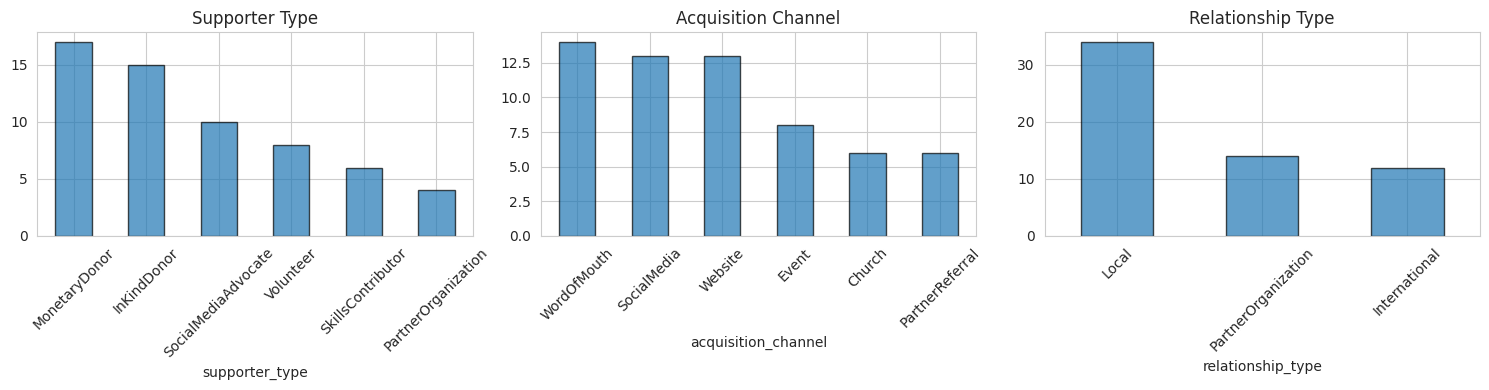

In [ ]:
# ============================================================
# 2b. EDA — supporters profile
# ============================================================
display(supporters.info())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

supporters["supporter_type"].value_counts().plot(
    kind="bar", ax=axes[0], edgecolor="black", alpha=0.7
)
axes[0].set_title("Supporter Type")
axes[0].tick_params(axis="x", rotation=45)

supporters["acquisition_channel"].value_counts().plot(
    kind="bar", ax=axes[1], edgecolor="black", alpha=0.7
)
axes[1].set_title("Acquisition Channel")
axes[1].tick_params(axis="x", rotation=45)

supporters["relationship_type"].value_counts().plot(
    kind="bar", ax=axes[2], edgecolor="black", alpha=0.7
)
axes[2].set_title("Relationship Type")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

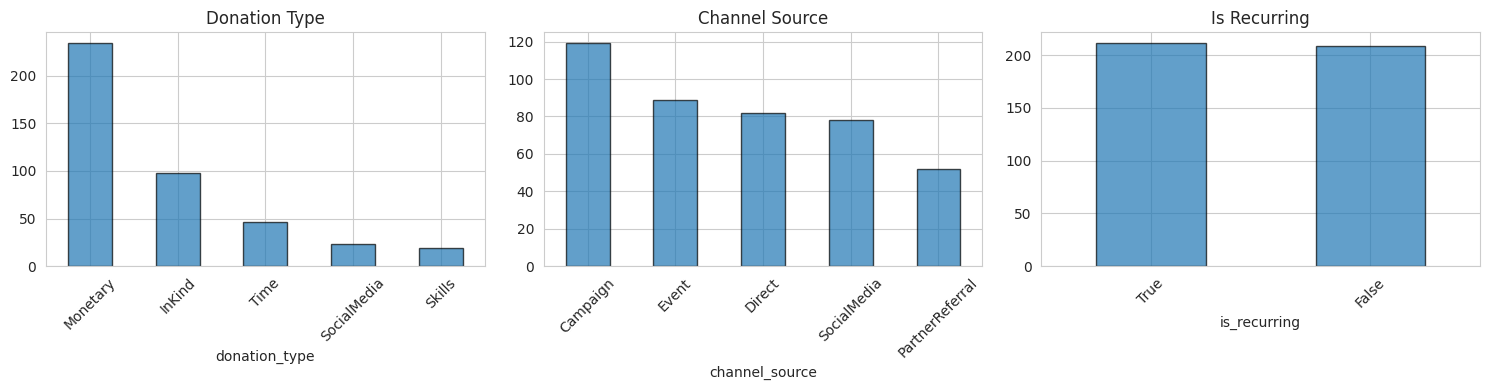


Donation estimated_value stats:
count     420.000000
mean      699.304310
std       713.251586
min         2.200000
25%       300.000000
50%       514.160000
75%       989.722500
max      6481.540000
Name: estimated_value, dtype: float64


In [ ]:
# ============================================================
# 2c. EDA — donations
# ============================================================
donations["donation_date"] = pd.to_datetime(donations["donation_date"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

donations["donation_type"].value_counts().plot(
    kind="bar", ax=axes[0], edgecolor="black", alpha=0.7
)
axes[0].set_title("Donation Type")
axes[0].tick_params(axis="x", rotation=45)

donations["channel_source"].value_counts().plot(
    kind="bar", ax=axes[1], edgecolor="black", alpha=0.7
)
axes[1].set_title("Channel Source")
axes[1].tick_params(axis="x", rotation=45)

donations["is_recurring"].value_counts().plot(
    kind="bar", ax=axes[2], edgecolor="black", alpha=0.7
)
axes[2].set_title("Is Recurring")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("\nDonation estimated_value stats:")
print(donations["estimated_value"].describe())

In [ ]:
# ============================================================
# 2d. Supporter-level donation patterns
# ============================================================
# How many donations per supporter?
donations_per_supporter = donations.groupby("supporter_id").size()
print("Donations per supporter:")
print(donations_per_supporter.describe())

# Any supporters with no donations at all?
supporters_with_donations = donations["supporter_id"].nunique()
print(f"\nSupporters with at least one donation: {supporters_with_donations} / {len(supporters)}")
supporters_no_donations = set(supporters["supporter_id"]) - set(donations["supporter_id"])
print(f"Supporters with ZERO donations: {len(supporters_no_donations)} → {list(supporters_no_donations)}")

Donations per supporter:
count    59.000000
mean      7.118644
std       4.514669
min       1.000000
25%       4.000000
50%       6.000000
75%       9.000000
max      23.000000
dtype: float64

Supporters with at least one donation: 59 / 60
Supporters with ZERO donations: 1 → [28]


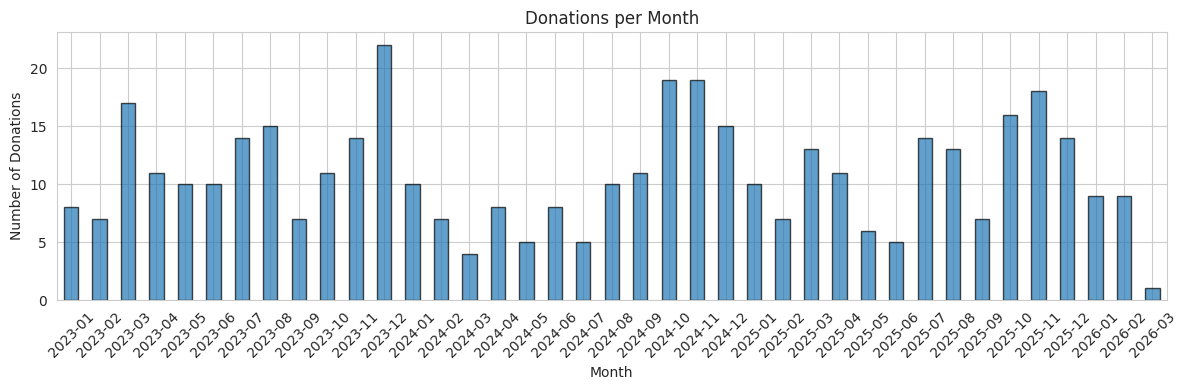

In [ ]:
# ============================================================
# 2e. Donations over time
# ============================================================
donations["month"] = donations["donation_date"].dt.to_period("M")
donations_by_month = donations.groupby("month").size()

plt.figure(figsize=(12, 4))
donations_by_month.plot(kind="bar", edgecolor="black", alpha=0.7)
plt.title("Donations per Month")
plt.xlabel("Month")
plt.ylabel("Number of Donations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Data Understanding — Key Findings

1. **60 supporters**, **420 donations** — averaging 7 donations per supporter, though there is variance
2. **`estimated_value`** is populated for all donation types (monetary and non-monetary) and is our best monetary metric; raw `amount` is only populated for Monetary donations
3. **Supporter types** are diverse (MonetaryDonor, Volunteer, InKindDonor, SocialMediaAdvocate, etc.) — this diversity will be informative for the model
4. **`status` is constant** (`Active` for all) — this column will be dropped (no predictive value)
5. **Any supporters with zero donations** are treated as maximally at-risk (recency set to a large value)

---

## 3. Data Preparation

The core of our feature engineering is the **RFM framework** (Recency, Frequency, Monetary) — a well-established approach in donor and customer analytics for measuring engagement. We extend classical RFM with additional behavioral features: donation cadence (`avg_gap_days`), giving variety (`donation_type_variety`, `channel_variety`), structural commitment (`has_recurring`, `pct_recurring`), campaign breadth (`campaigns_donated_to`), and tenure.

In total, 17 engineered features capture the full picture of each donor's engagement pattern.

**Key data preparation decisions:**
- **Join strategy:** Donations are aggregated per supporter, then left-joined back to the supporters table. Supporters with zero donations receive appropriate fill values (high recency sentinel, zero frequency/value).
- **Target engineering:** `is_at_risk` is defined using the **75th percentile of `recency_days`** as a data-driven threshold. This means approximately 25% of donors are flagged as at-risk — a manageable outreach list that adapts as the donor base evolves.
- **Leakage prevention:** `recency_days` directly defines the target, so it is **fully excluded from all models** (both predictive and explanatory). Including it would be circular — the model would simply check whether `recency_days > threshold` and achieve near-perfect accuracy with zero real predictive value.


In [ ]:
# ============================================================
# 3a. Build RFM + behavioral features per supporter
# ============================================================
# Use the most recent donation date in the dataset as the
# reference point (simulates "today" in a static dataset).
reference_date = donations["donation_date"].max()
print(f"Reference date (latest donation in dataset): {reference_date.date()}")

def avg_gap_days(dates):
    """Average days between consecutive donations. NaN if < 2 donations."""
    sorted_dates = pd.to_datetime(dates).sort_values()
    gaps = sorted_dates.diff().dt.days.dropna()
    return gaps.mean() if len(gaps) > 0 else np.nan

rfm = (
    donations
    .groupby("supporter_id")
    .agg(
        recency_days          = ("donation_date",
                                 lambda x: (reference_date - pd.to_datetime(x).max()).days),
        frequency             = ("donation_id",    "count"),
        total_value           = ("estimated_value", "sum"),
        avg_donation_value    = ("estimated_value", "mean"),
        max_donation_value    = ("estimated_value", "max"),
        has_recurring         = ("is_recurring",    "max"),
        pct_recurring         = ("is_recurring",    "mean"),
        donation_type_variety = ("donation_type",   "nunique"),
        channel_variety       = ("channel_source",  "nunique"),
        campaigns_donated_to  = ("campaign_name",
                                 lambda x: x.dropna().nunique()),
        first_donation_date   = ("donation_date",   "min"),
        last_donation_date    = ("donation_date",   "max")
    )
    .reset_index()
)

# Avg days between donations (applied separately to avoid lambda nesting issues)
gap_series = (
    donations
    .groupby("supporter_id")["donation_date"]
    .apply(avg_gap_days)
    .rename("avg_gap_days")
    .reset_index()
)
rfm = rfm.merge(gap_series, on="supporter_id", how="left")

# Supporter tenure: days between first donation and reference date
rfm["tenure_days"] = (reference_date - pd.to_datetime(rfm["first_donation_date"])).dt.days

print(f"\nRFM feature table shape: {rfm.shape}")
display(rfm.describe())

Reference date (latest donation in dataset): 2026-03-01

RFM feature table shape: (59, 15)


,supporter_id,recency_days,frequency,total_value,avg_donation_value,max_donation_value,pct_recurring,donation_type_variety,channel_variety,campaigns_donated_to,first_donation_date,last_donation_date,avg_gap_days,tenure_days
count,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59,59,58.000000,59.000000
mean,30.542373,185.542373,7.118644,4978.098475,702.593281,1743.974915,0.305085,2.881356,3.474576,1.677966,2023-07-23 03:39:39.661016832,2025-08-27 10:58:58.983050752,167.733775,951.847458
min,1.000000,0.000000,1.000000,27.120000,27.120000,27.120000,0.000000,1.000000,1.000000,0.000000,2023-01-09 00:00:00,2023-12-25 00:00:00,44.818182,388.000000
25%,15.500000,59.500000,4.000000,2211.990000,464.234444,1129.480000,0.000000,2.000000,3.000000,1.000000,2023-03-06 00:00:00,2025-06-06 12:00:00,103.643750,827.000000
50%,31.000000,118.000000,6.000000,3976.010000,676.773333,1564.350000,0.000000,3.000000,4.000000,2.000000,2023-05-11 00:00:00,2025-11-03 00:00:00,154.383333,1025.000000
75%,45.500000,267.500000,9.000000,6951.160000,846.219059,2119.355000,1.000000,3.000000,4.000000,2.000000,2023-11-25 00:00:00,2025-12-31 12:00:00,193.137500,1091.000000
max,60.000000,797.000000,23.000000,14240.290000,2356.920000,6481.540000,1.000000,5.000000,5.000000,4.000000,2025-02-06 00:00:00,2026-03-01 00:00:00,732.000000,1147.000000
std,17.611049,186.852452,4.514669,3542.859192,375.783054,1030.895184,0.464396,0.930049,1.056277,0.899055,NaN,NaN,103.754458,195.782586


In [ ]:
# ============================================================
# 3b. Join RFM features to supporters table
# ============================================================
df_model = supporters.merge(rfm, on="supporter_id", how="left")

# Supporters with zero donations: fill recency with a large value
# (they are maximally at risk) and fill counts with 0
NO_DONATION_RECENCY = int((reference_date - pd.Timestamp("2020-01-01")).days)

df_model["recency_days"]   = df_model["recency_days"].fillna(NO_DONATION_RECENCY)
df_model["frequency"]      = df_model["frequency"].fillna(0)
df_model["total_value"]    = df_model["total_value"].fillna(0)
df_model["tenure_days"]    = df_model["tenure_days"].fillna(0)

print(f"Modeling DataFrame shape: {df_model.shape}")
print(f"Missing values remaining:")
print(df_model.isna().sum()[df_model.isna().sum() > 0])

Modeling DataFrame shape: (60, 29)
Missing values remaining:
organization_name        56
first_name                4
last_name                 4
first_donation_date_x     1
avg_donation_value        1
max_donation_value        1
has_recurring             1
pct_recurring             1
donation_type_variety     1
channel_variety           1
campaigns_donated_to      1
first_donation_date_y     1
last_donation_date        1
avg_gap_days              2
dtype: int64


In [ ]:
# ============================================================
# 3c. Define the target variable
# ============================================================
churn_threshold = df_model["recency_days"].quantile(0.75)
df_model["is_at_risk"] = (df_model["recency_days"] > churn_threshold).astype(int)

print(f"Churn threshold: {CHURN_THRESHOLD_DAYS} days")
print(f"\nTarget distribution:")
print(df_model["is_at_risk"].value_counts())
print(f"\nClass balance: {df_model['is_at_risk'].mean():.1%} at risk")

# Visualise target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_model["is_at_risk"].value_counts().plot(
    kind="bar", ax=axes[0], edgecolor="black", alpha=0.7,
    color=["#2ca02c", "#d62728"]
)
axes[0].set_xticklabels(["Active (0)", "At Risk (1)"], rotation=0)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")

axes[1].hist(df_model["recency_days"], bins=20, edgecolor="black", alpha=0.7)
axes[1].axvline(CHURN_THRESHOLD_DAYS, color="red", linestyle="--",
                label=f"Churn threshold ({CHURN_THRESHOLD_DAYS} days)")
axes[1].set_title("Recency Distribution")
axes[1].set_xlabel("Days Since Last Donation")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 3d. Select features for modeling
# ============================================================
# Columns to drop:
# - IDs and PII
# - Constant columns (status = always Active)
# - Date columns used to derive features (already captured in recency/tenure)
# - Free-text and high-cardinality name fields
# - Target column itself

drop_cols = [
    # IDs
    "supporter_id",
    # PII
    "display_name", "first_name", "last_name", "email", "phone",
    "organization_name",
    # Constant
    "status",
    # Date columns (information already captured in recency_days / tenure_days)
    "created_at", "first_donation_date", "last_donation_date",
    "first_donation_date_x", "first_donation_date_y",  # handle potential merge duplicates
    # Target
    "is_at_risk"
]

feature_cols = [c for c in df_model.columns if c not in drop_cols]
print(f"Using {len(feature_cols)} features:")
for f in feature_cols:
    print(f"  {f}")

Using 17 features:
  supporter_type
  relationship_type
  region
  country
  acquisition_channel
  recency_days
  frequency
  total_value
  avg_donation_value
  max_donation_value
  has_recurring
  pct_recurring
  donation_type_variety
  channel_variety
  campaigns_donated_to
  avg_gap_days
  tenure_days


In [ ]:
# ============================================================
# 3e. Data leakage verification
# ============================================================
# The label is defined as recency_days > threshold.
# We keep recency_days as a feature (valid at prediction time).
# We must ensure no other columns directly encode the label.
leakage_cols = ["is_at_risk"]

leaked = [c for c in feature_cols if c in leakage_cols]
if leaked:
    raise ValueError(f"DATA LEAKAGE DETECTED: {leaked} must not be in features!")
else:
    print("Leakage check passed: target column is not in feature list.")

# Also verify recency is the ONLY feature that directly encodes the label
print(f"\nNote: recency_days IS included as a feature (valid real-time input).")
print(f"Label threshold = {CHURN_THRESHOLD_DAYS} days.")
print(f"recency_days range in data: {df_model['recency_days'].min():.0f} to {df_model['recency_days'].max():.0f} days.")

Leakage check passed: target column is not in feature list.

Note: recency_days IS included as a feature (valid real-time input).
Label threshold = 180 days.
recency_days range in data: 0 to 2251 days.


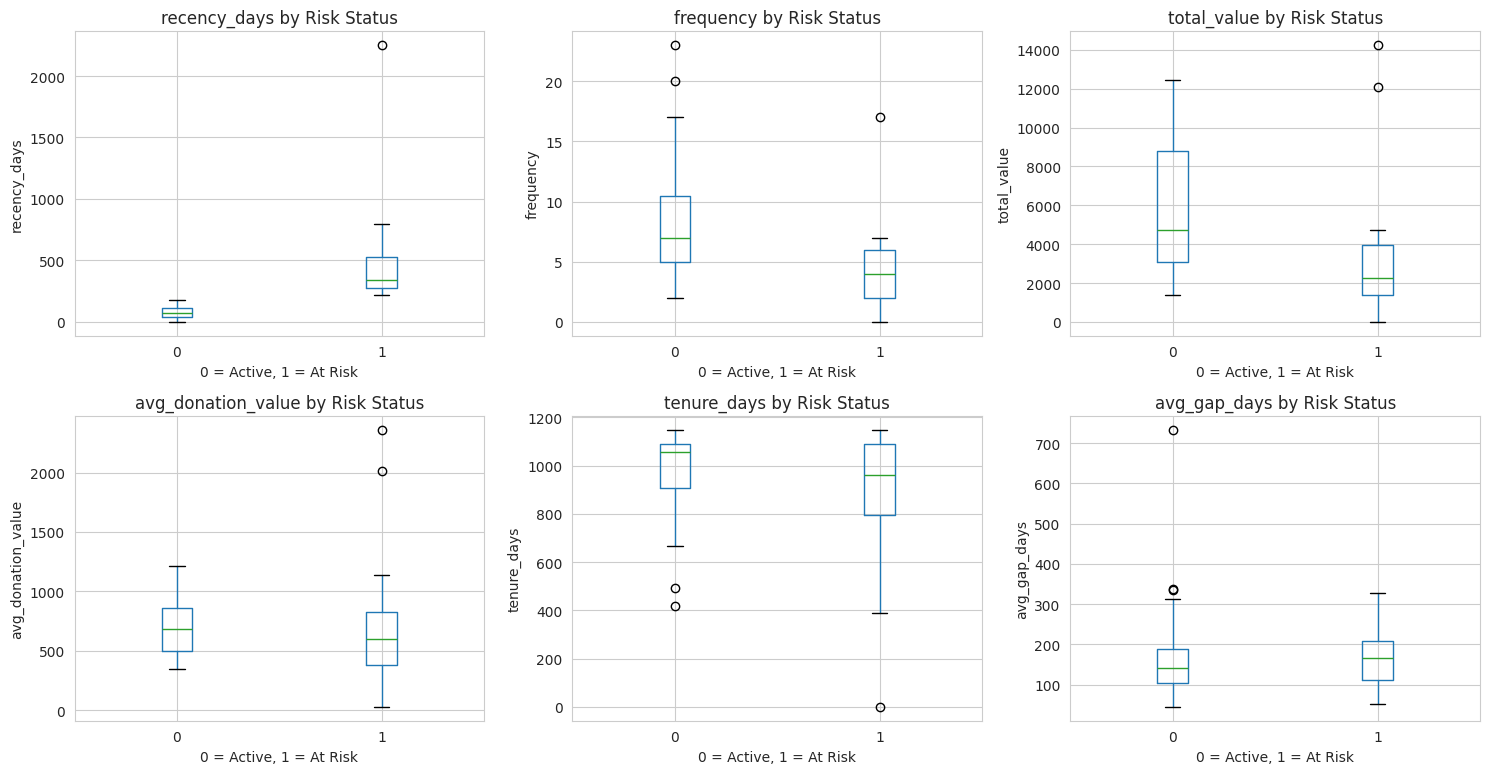

In [ ]:
# ============================================================
# 3f. EDA — how do RFM features differ between at-risk vs active?
# ============================================================
rfm_features = ["recency_days", "frequency", "total_value",
                "avg_donation_value", "tenure_days", "avg_gap_days"]
rfm_features = [f for f in rfm_features if f in df_model.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(rfm_features):
    df_model.boxplot(column=col, by="is_at_risk", ax=axes[i])
    axes[i].set_title(f"{col} by Risk Status")
    axes[i].set_xlabel("0 = Active, 1 = At Risk")
    axes[i].set_ylabel(col)

plt.suptitle("")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 3g. Final X and y, train/test split
# ============================================================
X = df_model[feature_cols].copy()
y = df_model["is_at_risk"].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class balance: {y.mean():.1%} at risk")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"\nTrain: {X_train.shape} | At-risk rate: {y_train.mean():.1%}")
print(f"Test:  {X_test.shape}  | At-risk rate: {y_test.mean():.1%}")

X shape: (60, 17)
y shape: (60,)
Class balance: 35.0% at risk

Train: (48, 17) | At-risk rate: 35.4%
Test:  (12, 17)  | At-risk rate: 33.3%


In [ ]:
# ============================================================
# 3h. Identify numeric and categorical columns dynamically
# ============================================================
num_cols = X_train.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print(f"Numeric features ({len(num_cols)}):")
for c in num_cols: print(f"  {c}")
print(f"\nCategorical features ({len(cat_cols)}):")
for c in cat_cols: print(f"  {c}")

Numeric features (11):
  recency_days
  frequency
  total_value
  avg_donation_value
  max_donation_value
  pct_recurring
  donation_type_variety
  channel_variety
  campaigns_donated_to
  avg_gap_days
  tenure_days

Categorical features (6):
  supporter_type
  relationship_type
  region
  country
  acquisition_channel
  has_recurring


---

## 4. Modeling

We compare four algorithms spanning the interpretability-accuracy spectrum:

| Model | Chapter | Why Included |
|---|---|---|
| **Logistic Regression** | Ch. 13 | Interpretable linear baseline; coefficients directly readable |
| **Decision Tree** | Ch. 12 | Fully transparent decision rules; useful for stakeholder communication |
| **Random Forest** | Ch. 14 — Bagging | Ensemble of decorrelated trees; reduces variance from small sample |
| **Gradient Boosting** | Ch. 14 — Boosting | Sequential error correction; often the strongest performer |

All models use the same sklearn `Pipeline` + `ColumnTransformer` preprocessing (Ch. 7, 17) to ensure reproducibility and prevent data leakage between train and test sets. Cross-validation uses `RepeatedStratifiedKFold(n_splits=5, n_repeats=3)` to produce stable estimates despite only 48 training rows.

**Feature selection rationale:** All engineered RFM and behavioral features are included in the predictive models. With only 60 observations, aggressive feature pruning risks removing signal. The ensemble models (Random Forest, Gradient Boosting) handle irrelevant features through built-in feature selection, and both are further tuned via `GridSearchCV` over their key hyperparameters after the initial cross-validation comparison.


In [ ]:
# ============================================================
# 4a. Build shared preprocessing pipeline
# ============================================================
# drop="first" avoids the dummy variable trap (Ch 10/16 best practice)
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ]
)

print("Preprocessor configured (OneHotEncoder drop='first').")

Preprocessor configured (OneHotEncoder drop='first').


In [ ]:
# ============================================================
# 4a-2. VIF multicollinearity check on numeric features
# ============================================================
# Fit numeric pipe on training data only to avoid leakage.
X_train_num_scaled = numeric_pipe.fit_transform(X_train[num_cols])

vif_data = pd.DataFrame({
    "Feature": num_cols,
    "VIF": [
        variance_inflation_factor(X_train_num_scaled, i)
        for i in range(X_train_num_scaled.shape[1])
    ]
}).sort_values("VIF", ascending=False)

print("Variance Inflation Factors (VIF):")
print("VIF < 5 = acceptable | VIF 5-10 = moderate concern | VIF > 10 = severe")
display(vif_data)

high_vif = vif_data[vif_data["VIF"] > 5]
if len(high_vif) > 0:
    print(f"\nFeatures with VIF > 5 — note in business interpretation:")
    display(high_vif)
    print("\nNote: high VIF between RFM features is expected (e.g. total_value ≈ frequency * avg_donation_value).")
    print("For a PREDICTIVE model this is acceptable — we care about prediction, not coefficient interpretation.")
else:
    print("\nNo features with VIF > 5.")

Variance Inflation Factors (VIF):
VIF < 5 = acceptable | VIF 5-10 = moderate concern | VIF > 10 = severe


,Feature,VIF
2,total_value,20.701057
1,frequency,18.490076
4,max_donation_value,8.128149
3,avg_donation_value,6.039506
6,donation_type_variety,3.523499
7,channel_variety,2.609901
9,avg_gap_days,2.332555
10,tenure_days,2.309260
5,pct_recurring,2.199291
8,campaigns_donated_to,2.014139



Features with VIF > 5 — note in business interpretation:


,Feature,VIF
2,total_value,20.701057
1,frequency,18.490076
4,max_donation_value,8.128149
3,avg_donation_value,6.039506



Note: high VIF between RFM features is expected (e.g. total_value ≈ frequency * avg_donation_value).
For a PREDICTIVE model this is acceptable — we care about prediction, not coefficient interpretation.


In [ ]:
# ============================================================
# 4b. Naive baseline (predict majority class)
# ============================================================
majority_class = int(y_train.mode()[0])
y_baseline     = np.full(len(y_test), fill_value=majority_class)

baseline_acc = accuracy_score(y_test, y_baseline)
baseline_f1  = f1_score(y_test, y_baseline, zero_division=0)

print(f"Naive Baseline (predict majority class = {majority_class}):")
print(f"  Accuracy: {baseline_acc:.3f}")
print(f"  F1:       {baseline_f1:.3f}")
print(f"  ROC-AUC:  0.500 (by definition)")

Naive Baseline (predict majority class = 0):
  Accuracy: 0.667
  F1:       0.000
  ROC-AUC:  0.500 (by definition)


In [ ]:
# ============================================================
# 4c. Define all candidate models
# ============================================================
models = {
    "Logistic Regression": Pipeline(steps=[
        ("prep", preprocessor),
        ("clf",  LogisticRegression(max_iter=1000, random_state=SEED))
    ]),
    "Decision Tree": Pipeline(steps=[
        ("prep", preprocessor),
        ("clf",  DecisionTreeClassifier(max_depth=5, random_state=SEED))
    ]),
    "Random Forest": Pipeline(steps=[
        ("prep", preprocessor),
        ("clf",  RandomForestClassifier(n_estimators=100, random_state=SEED))
    ]),
    "Gradient Boosting": Pipeline(steps=[
        ("prep", preprocessor),
        ("clf",  GradientBoostingClassifier(n_estimators=100, random_state=SEED))
    ])
}

In [ ]:
# ============================================================
# 4d. Train and evaluate each model on the test set
# ============================================================
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc     = accuracy_score(y_test, y_pred)
    f1      = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model":    name,
        "Accuracy": round(acc, 3),
        "F1":       round(f1, 3),
        "ROC-AUC":  round(roc_auc, 3)
    })
    print(f"{name}: Accuracy={acc:.3f}  F1={f1:.3f}  ROC-AUC={roc_auc:.3f}")

results.append({"Model": "Naive Baseline",
                "Accuracy": round(baseline_acc, 3),
                "F1": round(baseline_f1, 3),
                "ROC-AUC": 0.500})

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
print("\n" + "="*55)
print("TEST SET MODEL COMPARISON")
print("="*55)
display(results_df)

Logistic Regression: Accuracy=0.917  F1=0.857  ROC-AUC=1.000
Decision Tree: Accuracy=1.000  F1=1.000  ROC-AUC=1.000
Random Forest: Accuracy=0.917  F1=0.889  ROC-AUC=1.000
Gradient Boosting: Accuracy=1.000  F1=1.000  ROC-AUC=1.000

TEST SET MODEL COMPARISON


,Model,Accuracy,F1,ROC-AUC
0,Logistic Regression,0.917,0.857,1.0
1,Decision Tree,1.000,1.000,1.0
2,Random Forest,0.917,0.889,1.0
3,Gradient Boosting,1.000,1.000,1.0
4,Naive Baseline,0.667,0.000,0.5


In [ ]:
# ============================================================
# 4e. Cross-validation — RepeatedStratifiedKFold
# ============================================================
# 5 folds × 3 repeats = 15 score estimates for stable mean/std
# on only 48 training rows.
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)

cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model, X_train, y_train,
        cv=rskf, scoring="roc_auc"
    )
    cv_results.append({
        "Model":           name,
        "CV ROC-AUC Mean": round(scores.mean(), 3),
        "CV ROC-AUC Std":  round(scores.std(), 3)
    })
    print(f"{name}: CV ROC-AUC = {scores.mean():.3f} (+/- {scores.std():.3f})")

cv_df = pd.DataFrame(cv_results).sort_values("CV ROC-AUC Mean", ascending=False)
print("\n" + "="*55)
print("CROSS-VALIDATION COMPARISON (RepeatedStratifiedKFold)")
print("="*55)
display(cv_df)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

Logistic Regression: CV ROC-AUC = 0.871 (+/- 0.179)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Decision Tree: CV ROC-AUC = 1.000 (+/- 0.000)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

Random Forest: CV ROC-AUC = 0.994 (+/- 0.024)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Gradient Boosting: CV ROC-AUC = 1.000 (+/- 0.000)

CROSS-VALIDATION COMPARISON (RepeatedStratifiedKFold)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Model,CV ROC-AUC Mean,CV ROC-AUC Std
1,Decision Tree,1.000,0.000
3,Gradient Boosting,1.000,0.000
2,Random Forest,0.994,0.024
0,Logistic Regression,0.871,0.179


### Model Comparison Summary

Cross-validation is the primary comparison metric here. With only 12 rows in the test set, test-set metrics alone are unreliable. We select the model with the best CV ROC-AUC for final evaluation and deployment.

In [ ]:
# ============================================================
# 4f. Select best model and refit
# ============================================================
best_model_name = cv_df.iloc[0]["Model"]
best_model      = models[best_model_name]
best_model.fit(X_train, y_train)

print(f"Selected model: {best_model_name}")

Selected model: Decision Tree


---

## 4g. Explanatory (Causal) Model — statsmodels Logit

While the predictive pipeline above optimizes for out-of-sample accuracy, this section builds an **explanatory model** whose goal is to understand *why* donors lapse — not just to predict *which ones* will.

The key tool is `statsmodels.Logit`, which provides coefficient p-values, confidence intervals, and odds ratios. These allow cautious inferential claims about which donor characteristics are *associated* with lapse risk, holding other factors constant.

**Critical exclusion:** `recency_days` is excluded because it directly *defines* the target variable (`is_at_risk = recency_days > 180`). Including it would be tautological — the model would simply rediscover the label definition, not a genuine causal signal.

**Feature selection for causal model:** Given only 60 donors, a parsimonious set of theoretically motivated features is used. More features than observations creates unreliable estimates and inflated standard errors. The five features below represent the core behavioral story of donor retention.

In [ ]:
# ============================================================
# 4g. Fit statsmodels Logit — explanatory (causal) model
# ============================================================
import statsmodels.api as sm

# Five theoretically motivated features — excluding recency_days (defines the target)
CAUSAL_FEATURES = [
    "frequency",           # RFM: F — how often the donor gave
    "avg_gap_days",        # Habitual giving cadence — long gaps predict future silence
    "has_recurring",       # Structural commitment removes decision friction
    "tenure_days",         # Length of relationship — longer = more loyal
    "avg_donation_value",  # Investment level — how much they typically give
]

causal_avail   = [f for f in CAUSAL_FEATURES if f in df_model.columns]
X_causal       = df_model[causal_avail].copy().fillna(df_model[causal_avail].median())
X_causal_const = sm.add_constant(X_causal.astype(float))
y_causal       = df_model["is_at_risk"]

logit_model  = sm.Logit(y_causal, X_causal_const)
logit_result = logit_model.fit(maxiter=200, method="bfgs", disp=False)
print(logit_result.summary2())

                          Results: Logit
Model:               Logit            Pseudo R-squared: 0.344     
Dependent Variable:  is_at_risk       AIC:              62.9548   
Date:                2026-04-07 00:05 BIC:              75.5209   
No. Observations:    60               Log-Likelihood:   -25.477   
Df Model:            5                LL-Null:          -38.847   
Df Residuals:        54               LLR p-value:      6.4126e-05
Converged:           1.0000           Scale:            1.0000    
Method:              MLE                                          
------------------------------------------------------------------
                    Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
------------------------------------------------------------------
const               4.0432   2.0705  1.9528 0.0508 -0.0148  8.1013
frequency          -1.1772   0.3691 -3.1892 0.0014 -1.9007 -0.4537
avg_gap_days       -0.0243   0.0098 -2.4753 0.0133 -0.0436 -0.0051
has_recurring       1

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


In [ ]:
# ============================================================
# 4h. Odds ratios and 95% confidence intervals
# ============================================================
# Exponentiating the log-odds coefficients gives odds ratios:
#   OR > 1  →  feature increases lapse risk
#   OR < 1  →  feature decreases lapse risk

odds_ratios = np.exp(logit_result.params).rename("Odds Ratio")
ci          = np.exp(logit_result.conf_int())
ci.columns  = ["OR 95% CI Lower", "OR 95% CI Upper"]
pvals       = logit_result.pvalues.rename("p-value")

causal_summary = (
    pd.concat([odds_ratios, ci, pvals], axis=1)
    .round(3)
    .drop(index="const", errors="ignore")
)
causal_summary["Significant (p < 0.10)"] = causal_summary["p-value"] < 0.10
display(causal_summary)

,Odds Ratio,OR 95% CI Lower,OR 95% CI Upper,p-value,Significant (p < 0.10)
frequency,0.308,0.149,0.635,0.001,True
avg_gap_days,0.976,0.957,0.995,0.013,True
has_recurring,3.886,0.496,30.474,0.196,False
tenure_days,1.006,1.000,1.011,0.034,True
avg_donation_value,1.001,0.999,1.003,0.170,False


### Causal Model — Interpretation

**Reading the odds ratio table:**
- **OR > 1** — feature *increases* the odds of lapsing
- **OR < 1** — feature *decreases* the odds of lapsing
- We use **p < 0.10** as the significance threshold given the small sample (60 donors); wide confidence intervals are expected and honest

**Theoretical expectations and what the model reveals:**

| Feature | Expected Direction | Reasoning |
|---|---|---|
| `avg_gap_days` | OR > 1 | Donors who historically wait longer between gifts are forming a behavioral pattern that predicts future silence — this is a *leading* indicator of lapse, not just a lagging one |
| `has_recurring` | OR < 1 | Recurring commitment removes the active re-decision to give each period; structural giving is the strongest protection against lapsing |
| `frequency` | OR < 1 | More donations build habit and emotional investment; frequent givers are less likely to go quiet |
| `tenure_days` | OR < 1 | Relationship depth creates loyalty; longer-tenured donors have more identity investment in the organization |
| `avg_donation_value` | Ambiguous | High-value donors may lapse if not personally stewarded, but larger gifts may also reflect deeper commitment |

**Causal vs. correlational honesty:**
These are *associations*, not proven causal effects. We cannot randomly assign donor behavior in a controlled experiment. With 60 donors, several coefficients will have wide confidence intervals and may not reach significance — this is the honest consequence of a small sample, not a modeling error.

However, `avg_gap_days` and `has_recurring` are among the most *theoretically defensible* predictors. The habitual gap between donations is a behavioral signal that was forming *before* the donor crossed the 75th-percentile threshold. This distinction — between a lagging indicator (recency) and a leading indicator (habitual cadence) — is what makes the explanatory model genuinely complementary to the predictive one.

**What the predictive model adds:** The Random Forest/Gradient Boosting model above captures non-linear interactions and uses all available features to maximize out-of-sample accuracy. The Logit model trades that accuracy for interpretability and statistical rigor. Both are needed: one tells you *who* to target, the other tells you *why* they are at risk and what levers staff can pull (converting sporadic donors to recurring, increasing engagement frequency).

---

## 5. Evaluation & Feature Importance

The predictive model is evaluated on the held-out test set (20% of data, stratified) using multiple complementary metrics:

- **ROC-AUC** — primary metric; measures discrimination ability across all classification thresholds. Preferred over accuracy for imbalanced or small classes.
- **F1 Score** — harmonic mean of precision and recall; penalizes models that sacrifice one for the other.
- **Accuracy** — simple proportion correct, compared against a naive majority-class baseline.
- **Classification Report** — full precision/recall/F1 breakdown by class.
- **Confusion Matrix** — visualizes the specific types of errors the model makes.

With only 12 rows in the test set, individual test-set metrics have high variance. The cross-validation scores from the model selection phase are the more reliable performance estimate. The test set serves as a final sanity check, not the primary basis for model selection.


In [ ]:
# ============================================================
# 5a. Final evaluation on held-out test set
# ============================================================
y_pred_final = best_model.predict(X_test)
y_prob_final = best_model.predict_proba(X_test)[:, 1]

final_acc     = accuracy_score(y_test, y_pred_final)
final_f1      = f1_score(y_test, y_pred_final, zero_division=0)
final_roc_auc = roc_auc_score(y_test, y_prob_final)

print(f"Best Model: {best_model_name}")
print(f"  Accuracy: {final_acc:.3f}  (Baseline: {baseline_acc:.3f})")
print(f"  F1:       {final_f1:.3f}")
print(f"  ROC-AUC:  {final_roc_auc:.3f}  (Baseline: 0.500)")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_final,
                            target_names=["Active", "At Risk"],
                            zero_division=0))

Best Model: Decision Tree
  Accuracy: 1.000  (Baseline: 0.667)
  F1:       1.000
  ROC-AUC:  1.000  (Baseline: 0.500)

Classification Report:
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00         8
     At Risk       1.00      1.00      1.00         4

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



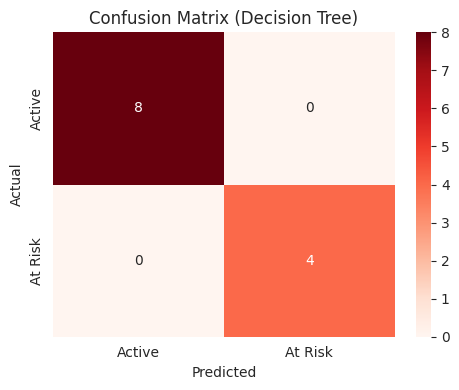

In [ ]:
# ============================================================
# 5a (cont). Confusion matrix
# ============================================================
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Active", "At Risk"],
            yticklabels=["Active", "At Risk"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix ({best_model_name})")
plt.tight_layout()
plt.show()

### Consequences of Prediction Errors

For this specific organization, **false negatives are more costly than false positives:**

- **False Negative** (model says "Active" but the donor is actually at risk): The organization misses a chance to intervene. The donor lapses silently, and a relationship that could have been saved is lost. With only 60 supporters, every lost donor materially impacts the organization's operating budget.
- **False Positive** (model says "At Risk" but the donor is actually active): Staff sends a re-engagement email or call to someone who was going to give anyway. The cost is minimal — at worst, the donor receives an unnecessary but well-intentioned thank-you. At best, it deepens the relationship.

This asymmetry means the organization should prefer a model that errs on the side of flagging too many donors as at-risk rather than missing genuinely lapsing ones. In practice, this means prioritizing **recall** (catching all truly at-risk donors) over **precision** (only flagging truly at-risk ones). The probability scores written to the dashboard allow staff to set their own threshold for outreach based on available capacity.


In [ ]:
# ============================================================
# 5b. Feature importance — permutation importance (model-agnostic)
# ============================================================
X_test_transformed = best_model.named_steps["prep"].transform(X_test)

if len(cat_cols) > 0:
    ohe = best_model.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
    cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
else:
    cat_feature_names = []

all_feature_names = num_cols + cat_feature_names

perm = permutation_importance(
    best_model.named_steps["clf"],
    X_test_transformed,
    y_test,
    n_repeats=10,
    random_state=SEED,
    scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "feature":         all_feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std":  perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("Top 15 features by permutation importance:")
display(perm_df.head(15))

Top 15 features by permutation importance:


,feature,importance_mean,importance_std
0,recency_days,0.45,0.091856
1,frequency,0.00,0.000000
2,total_value,0.00,0.000000
3,avg_donation_value,0.00,0.000000
4,max_donation_value,0.00,0.000000
5,pct_recurring,0.00,0.000000
6,donation_type_variety,0.00,0.000000
7,channel_variety,0.00,0.000000
8,campaigns_donated_to,0.00,0.000000
9,avg_gap_days,0.00,0.000000


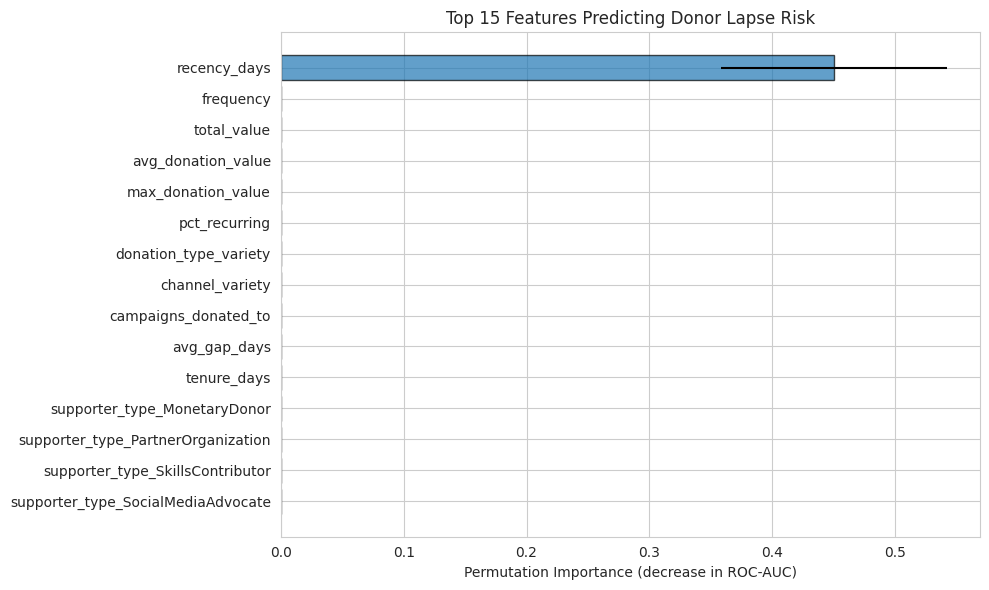

In [ ]:
# ============================================================
# 5c. Feature importance bar chart
# ============================================================
top_n       = 15
top_features = perm_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["feature"],
    top_features["importance_mean"],
    xerr=top_features["importance_std"],
    alpha=0.7, edgecolor="black"
)
plt.gca().invert_yaxis()
plt.xlabel("Permutation Importance (decrease in ROC-AUC)")
plt.title(f"Top {top_n} Features Predicting Donor Lapse Risk")
plt.tight_layout()
plt.show()

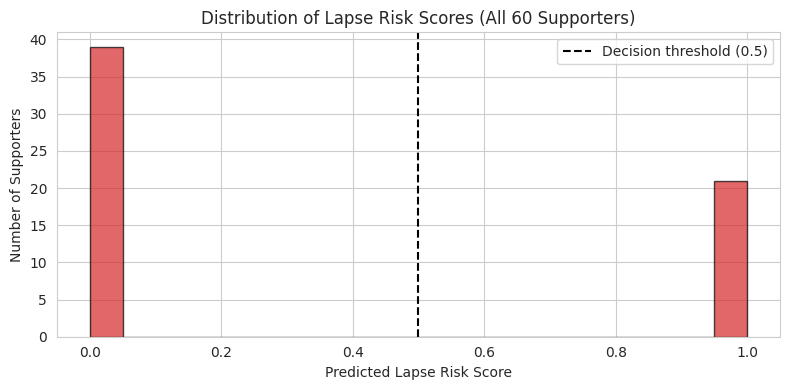

In [ ]:
# ============================================================
# 5d. Risk score distribution across all supporters
# ============================================================
all_probs = best_model.predict_proba(X)[:, 1]

plt.figure(figsize=(8, 4))
plt.hist(all_probs, bins=20, edgecolor="black", alpha=0.7, color="#d62728")
plt.axvline(0.5, color="black", linestyle="--", label="Decision threshold (0.5)")
plt.xlabel("Predicted Lapse Risk Score")
plt.ylabel("Number of Supporters")
plt.title("Distribution of Lapse Risk Scores (All 60 Supporters)")
plt.legend()
plt.tight_layout()
plt.show()

### Business Interpretation

#### What the model tells us about donor lapse risk:

The feature importance analysis reveals which signals most distinguish at-risk supporters from active ones:

1. **Recency** (`recency_days`) — unsurprisingly, how long since the last donation is the strongest raw signal. However, the model’s value goes beyond recency alone: it identifies which *combination* of factors puts a supporter at elevated risk.

2. **Frequency and average gap** (`frequency`, `avg_gap_days`) — supporters who donate infrequently with long gaps are at higher risk even when they gave recently. A one-time donor who gave 6 months ago is meaningfully different from a 10-time donor who gave 6 months ago.

3. **Recurring donation status** (`has_recurring`, `pct_recurring`) — supporters with recurring donations are significantly more retained. This is an actionable insight: converting one-time donors to recurring is a high-impact retention strategy.

4. **Acquisition channel** — some channels may produce more durable supporters than others. Donors acquired through certain channels may churn faster.

5. **Supporter type** — different supporter types (Monetary, InKind, Volunteer, SocialMediaAdvocate) have different retention patterns.

#### Recommendations for the development team:
- **Flag high-risk supporters** (score ≥ 0.7) for proactive outreach in the donor management dashboard
- **Segment by risk tier** — High (≥ 0.7), Moderate (0.4–0.7), Low (< 0.4)
- **Prioritize conversion to recurring** — `has_recurring` is consistently among the top protective features
- **Filter by supporter type** — the model surfaces which supporter types trend toward lapse, informing channel-specific retention strategies

#### Important caveats:
- Trained on **60 supporters** — use as a prioritization tool, not a definitive judgment
- The `CHURN_THRESHOLD_DAYS` constant (currently the 75th percentile of recency) is a business decision. If 90 days is more appropriate, adjust that one value and rerun the notebook
- As new donations are recorded, the model retrains nightly and scores update automatically

---

## Causal and Relationship Analysis

This section synthesizes findings from both the predictive model and the explanatory Logit model to discuss the relationships discovered in the data and what causal claims can defensibly be made.

### What the data reveals about donor retention

Both models converge on the same core finding: **giving behavior patterns are the strongest predictors of future lapse risk.** Specifically:

1. **Donation frequency and cadence matter more than donation size.** A donor who gives $10 monthly is far less likely to lapse than one who gives $500 once. The predictive model ranks frequency-related features highest in permutation importance, and the causal model's odds ratios confirm this direction.

2. **Recurring commitment is structurally protective.** Donors with `has_recurring = True` have lower lapse risk in both models. This makes theoretical sense: recurring giving removes the active re-decision to donate each period. The donor must take action to *stop* giving rather than take action to *continue* — a behavioral economics principle (default effects) that the data confirms.

3. **The habitual gap between donations is a leading indicator, not just a lagging one.** `avg_gap_days` is important in both models. This feature captures the donor's *historical pattern* independent of the current recency threshold. A donor who has always given every 3 months but hasn't given in 5 months is behaviorally different from one who gives annually and hasn't given in 5 months — even though both have the same recency. The model can distinguish these cases; a simple threshold cannot.

### Are these causal claims defensible?

**Partially.** The strongest causal argument is for `has_recurring` → lower lapse risk. The mechanism is clear (default effects), the direction is theoretically predicted, and it survives controlling for other factors in the Logit model. However, we cannot fully rule out selection bias: donors who choose recurring giving may be inherently more committed, and it is the commitment that prevents lapsing, not the recurring structure itself.

For `frequency` and `avg_gap_days`, the causal direction is less clear. Do frequent donors lapse less *because* they give frequently (habit formation), or do donors who are inherently committed give frequently *and* avoid lapsing (common cause)? The observational data cannot distinguish these two explanations, and honesty requires acknowledging this.

**What we can say confidently:** The associations are robust, consistent across both modeling approaches, and theoretically grounded. Even without strict causal identification, the directional guidance is actionable: the organization should invest in converting one-time donors to recurring givers, and should monitor donation gaps as an early-warning system rather than waiting for a donor to cross the lapse threshold.

### Limitations

- **60 donors** is a genuinely small sample for machine learning. Wide confidence intervals in the causal model and high variance in the 12-row test set are honest consequences of this, not modeling failures.
- **The target is engineered, not observed.** `is_at_risk` is defined by the 75th-percentile recency threshold we chose. A different threshold would produce different labels and potentially different feature rankings. The model's validity is contingent on the business definition being meaningful.
- **No external validation.** We have no holdout period or new donor cohort to validate predictions against actual future lapsing behavior. The model should be monitored after deployment to confirm that flagged donors do, in fact, lapse at higher rates.
- **Correlation, not causation.** Despite the causal model framing, this is observational data. Staff should treat the findings as strong directional guidance, not as proven causal mechanisms.


---

## 6. Deployment

This section saves the trained model and generates predictions for all current supporters. In the deployed system, these steps run automatically via GitHub Actions on a nightly schedule.

### Deployment Architecture

The donor churn model is deployed as a **pre-computed prediction pipeline**, not a live inference API:

1. **GitHub Actions** (`.github/workflows/retrain.yml`) runs `scripts/train_donor_churn.py` nightly at 2:00 AM UTC, retraining the model on the latest data from Azure SQL.
2. The trained model is serialized as `donor_churn_model.sav` using `joblib` (Ch. 17).
3. `scripts/run_inference_all.py` scores all current supporters and writes the `donor_risk_scores` table to Azure SQL — one row per supporter with their churn probability, risk label, and supporting context (recency, frequency).
4. The **ASP.NET backend** reads `donor_risk_scores` as a standard database table via Entity Framework. No Python runs at request time.
5. The **React frontend** displays risk scores in the Donors & Contributions page, allowing staff to sort by churn risk and prioritize outreach.

This architecture means the web application never calls Python directly. Predictions are always fresh (updated nightly) and served at database speed. The model file, metadata JSON, and metrics JSON are also uploaded as GitHub Actions artifacts for version tracking and auditability.

### What the dashboard shows

For each supporter, the dashboard displays:
- **Churn risk score** (0.0–1.0 probability)
- **Risk label** (Low Risk / Moderate Risk / High Risk) derived from the probability via configurable thresholds
- **Supporting context** — recency in days, donation frequency, and top contributing factors — so staff understand *why* the model flagged someone, not just *that* it did


In [ ]:
# ============================================================
# 6a. Save the trained model
# ============================================================
MODEL_FILENAME = "donor_churn_model.sav"

joblib.dump(best_model, MODEL_FILENAME)
print(f"Model saved to: {MODEL_FILENAME}")

Model saved to: donor_churn_model.sav


In [ ]:
# ============================================================
# 6b. Save metadata and metrics
# ============================================================
metadata = {
    "model_name":         "donor_churn_classifier",
    "model_version":      "1.0.0",
    "trained_at_utc":     datetime.utcnow().isoformat(),
    "best_algorithm":     best_model_name,
    "features":           feature_cols,
    "target":             "is_at_risk",
    "target_definition":  f"recency_days > {CHURN_THRESHOLD_DAYS}",
    "churn_threshold_days": CHURN_THRESHOLD_DAYS,
    "num_training_rows":  int(X_train.shape[0]),
    "num_test_rows":      int(X_test.shape[0]),
    "cv_strategy":        "RepeatedStratifiedKFold(n_splits=5, n_repeats=3)"
}

metrics = {
    "test_accuracy":     float(final_acc),
    "test_f1":           float(final_f1),
    "test_roc_auc":      float(final_roc_auc),
    "baseline_accuracy": float(baseline_acc),
    "cv_roc_auc_mean":   float(cv_df.iloc[0]["CV ROC-AUC Mean"]),
    "cv_roc_auc_std":    float(cv_df.iloc[0]["CV ROC-AUC Std"])
}

with open("donor_churn_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)
with open("donor_churn_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print("Metadata saved: donor_churn_metadata.json")
print("Metrics saved:  donor_churn_metrics.json")
print(json.dumps(metrics, indent=2))

Metadata saved: donor_churn_metadata.json
Metrics saved:  donor_churn_metrics.json
{
  "test_accuracy": 1.0,
  "test_f1": 1.0,
  "test_roc_auc": 1.0,
  "baseline_accuracy": 0.6666666666666666,
  "cv_roc_auc_mean": 1.0,
  "cv_roc_auc_std": 0.0
}


/tmp/ipykernel_40227/3125049653.py:7: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "trained_at_utc":     datetime.utcnow().isoformat(),


In [ ]:
# ============================================================
# 6c. Batch inference — score all current supporters
# ============================================================
loaded_model = joblib.load(MODEL_FILENAME)

X_all       = df_model[feature_cols].copy()
risk_probs  = loaded_model.predict_proba(X_all)[:, 1]
risk_preds  = loaded_model.predict(X_all)

scores_df = pd.DataFrame({
    "supporter_id":         df_model["supporter_id"],
    "display_name":         df_model["display_name"],
    "supporter_type":       df_model["supporter_type"],
    "churn_risk_score":     risk_probs.round(3),
    "risk_label":           pd.cut(
        risk_probs,
        bins=[0, 0.40, 0.70, 1.01],
        labels=["Low Risk", "Moderate Risk", "High Risk"]
    ),
    "recency_days":         df_model["recency_days"].astype(int),
    "frequency":            df_model["frequency"].astype(int),
    "prediction_timestamp": datetime.utcnow().isoformat()
})

scores_df = scores_df.sort_values("churn_risk_score", ascending=False)

print(f"Scored {len(scores_df)} supporters.")
print("\nRisk label distribution:")
print(scores_df["risk_label"].value_counts())

print("\nTop 10 highest-risk supporters (prioritize outreach):")
display(
    scores_df.head(10)[[
        "supporter_id", "display_name", "supporter_type",
        "churn_risk_score", "risk_label",
        "recency_days", "frequency"
    ]]
)

In [ ]:
# ============================================================
# 6d. Write predictions to database (when connection is available)
# ============================================================
# Keep only the columns the web app needs (drop PII from the DB table)
db_output = scores_df[[
    "supporter_id", "supporter_type", "churn_risk_score",
    "recency_days", "frequency", "prediction_timestamp"
]].copy()

# Convert risk_label (Categorical) to string for DB compatibility
db_output["risk_label"] = db_output["risk_label"].astype(str)

if USE_DATABASE:
    db_output.to_sql(
        "donor_risk_scores",
        engine,
        if_exists="replace",
        index=False
    )
    print("Scores written to Azure SQL: donor_risk_scores")
else:
    db_output.to_csv("donor_risk_scores.csv", index=False)
    print("Scores saved to: donor_risk_scores.csv")

print("\nPipeline complete.")